# IMPORT MODULES, INSTANTIATE CLASS

In [1]:
from geoai.utils_geo.raster_ops import RasterOperations

raster_ops = RasterOperations()

# READ RASTER METADATA

In [2]:
RASTER_FILE_PATH = "raster_files/QC_2018_2023.tif"
raster_metadata = raster_ops.read_raster_metadata(RASTER_FILE_PATH)
print(raster_metadata)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 496, 'height': 319, 'count': 5, 'crs': CRS.from_epsg(4326), 'transform': Affine(8.983152841195215e-05, 0.0, 121.03145553387772,
       0.0, -8.983152841195215e-05, 14.6650868447796)}


# READ RASTER AS ARRAY

In [3]:
raster_as_array = raster_ops.raster_to_array(RASTER_FILE_PATH)
print(raster_as_array.shape)

(5, 319, 496)


# COMPUTE FOR NDVI 

Band mapping are as follows:

{"BLUE": 0, "GREEN": 1, "RED": 2, "NIR": 3, "SWIR1": 4}

In [4]:
# get the RED and NIR band
red = raster_as_array[2]
nir = raster_as_array[3]

# compute ndvi
ndvi = raster_ops.compute_ndvi(nir, red)

# VISUALIZE

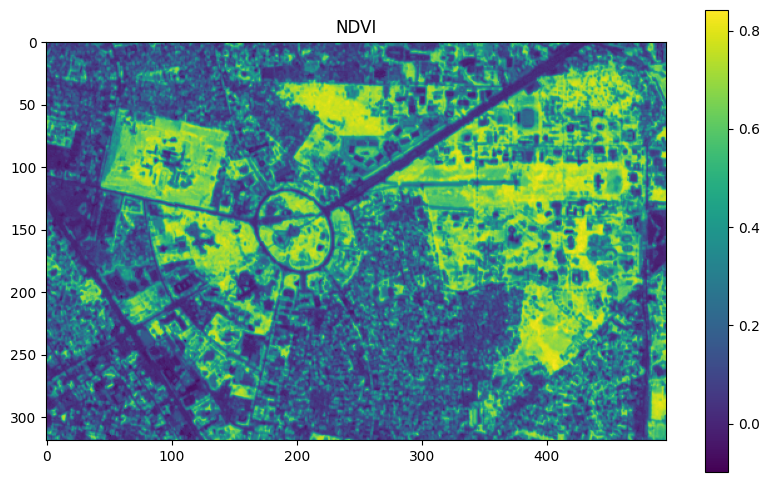

In [5]:
raster_ops.visualize_array(ndvi, "NDVI")

# MASK NON VEGETATION AREAS BASED ON NDVI VALUES

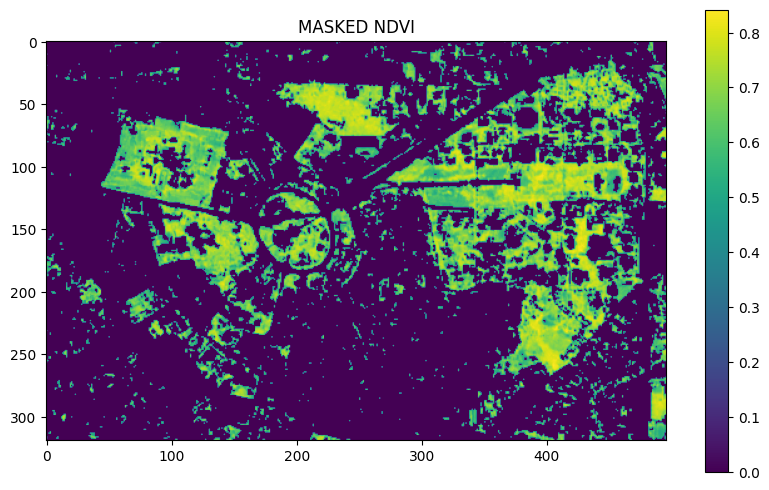

In [6]:
# DEFINE THRESHOLD
ndvi_threshold = 0.5

# CREATE A MASK RASTER
non_vegetation_mask = ndvi < ndvi_threshold # True for non-vegetation, False for vegetation

# APPLY THE MASK
vegetation_ndvi = raster_ops.apply_mask(ndvi, non_vegetation_mask, mask_value=0)

# VISUALIZE THE MASKED DATA
raster_ops.visualize_array(vegetation_ndvi, "MASKED NDVI")

# EXPORT

In [7]:
ndvi_masked_path = "raster_files/ndvi_masked.tif"
raster_ops.export_raster(vegetation_ndvi, raster_metadata, ndvi_masked_path)

In [8]:
# EXPORT MULTI-BAND RASTER
rgbnirndvi_path = "raster_files/multiband_ndvi.tif"
rgbnirndvi = raster_ops.add_band(raster_as_array, raster_metadata, ndvi)
raster_ops.export_raster(rgbnirndvi, raster_metadata, rgbnirndvi_path)

END